In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random as rd

## Hceho por: Lucian Valle Aguilar
## C.C 1066866114

# 1. Construya un DataFrame de pandas con un conjunto de datos lineales simples.

In [5]:
n = 100
x = np.linspace(0,10,n)   
theta_true = np.array([0.5, 3])    

y = theta_true[0] + theta_true[1] * x 

df = pd.DataFrame({"x":x , "y": y})
df



,x,y
0,0.00000,0.500000
1,0.10101,0.803030
2,0.20202,1.106061
3,0.30303,1.409091
4,0.40404,1.712121
...,...,...
95,9.59596,29.287879
96,9.69697,29.590909
97,9.79798,29.893939
98,9.89899,30.196970


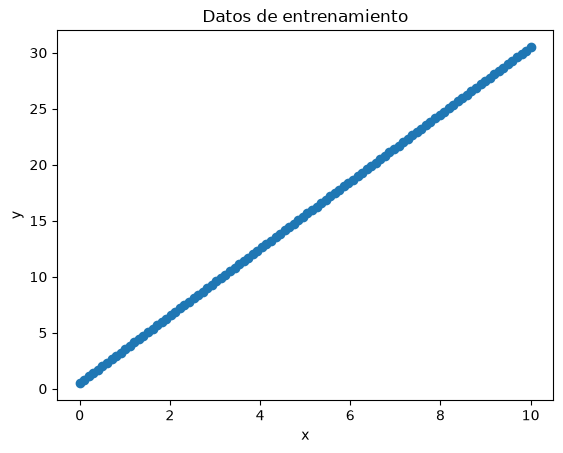

In [6]:
plt.plot(df["x"],df["y"], "o")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Datos de entrenamiento")
plt.show()

# 2. Defina una función que calcule la función de coste cuadrática para un modelo de regresión lineal.

In [7]:
def func_coste(x,y,theta, theta_0 ):
  j = 0
  m = len(x)
  for i in range(m):
    h = theta_0 + theta * x[i]
    j += (h - y[i]) ** 2
  j = j / (2*m) 
  return j

# 3. Fijando inicialmente $\theta_0 = 0$, evalúe y grafique la función de coste para diferentes valores de $\theta_1$. Determine el valor que minimiza la función de coste y grafique la recta obtenida sobre los datos.

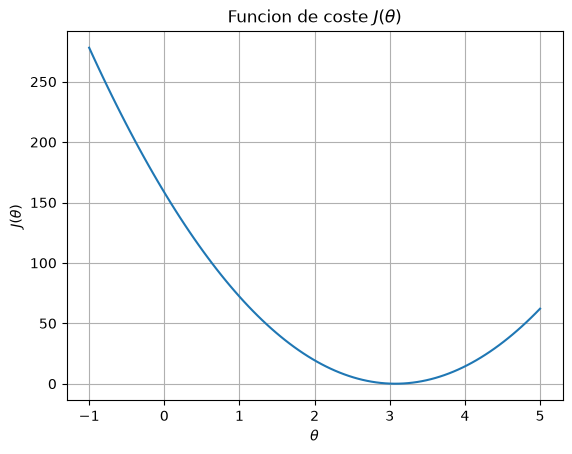

In [8]:
theta = np.linspace(-1,5,100)
theta_zeros = np.zeros(len(theta))
j = np.zeros(len(theta))

for i in range(len(theta)):
  j[i] = func_coste(df["x"],df["y"],theta[i],theta_zeros[i])

plt.plot(theta,j)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$J(\theta)$")
plt.title(r"Funcion de coste $J(\theta)$")
plt.grid()
plt.show()

# 4. Permita ahora que tanto $\theta_0$ como $\theta_1$ varíen. Construya una malla con np.meshgrid, evalúe la función de coste en cada punto y represente su superficie y curvas de nivel.

In [9]:
X, Y = np.meshgrid(theta, theta)

Z = np.zeros((len(theta),len(theta)))

for i in range(len(theta)):
  for j in range(len(theta)):
    Z[i,j] = func_coste(df["x"],df["y"],theta[j], theta[i])


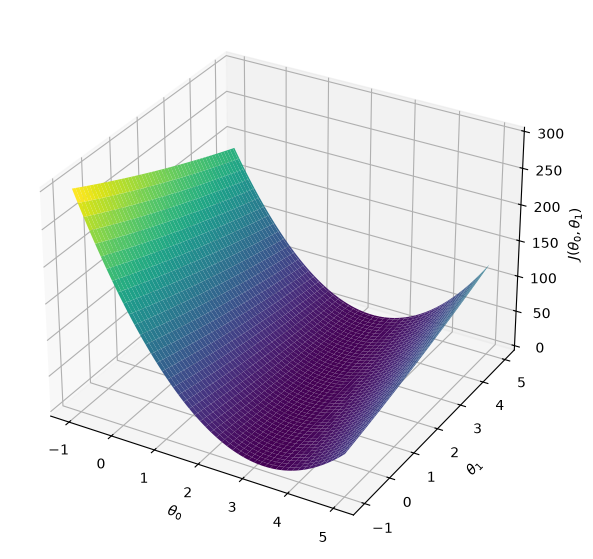

In [10]:
fig = plt.figure(figsize=(10,7))
ax = plt.axes( projection='3d')

ax.plot_surface(X, Y, Z, cmap='viridis')
ax.set_xlabel(r"$\theta_0$")
ax.set_ylabel(r"$\theta_1$")
ax.set_zlabel(r"$J(\theta_0, \theta_1)$")
plt.show()


# 5. Interprete geométricamente la forma de la función de coste e identifique el mínimo global.

In [11]:
# Minimo global

Z_min = np.min(Z)
x_m, y_m = np.unravel_index(np.argmin(Z), Z.shape)

X_min = X[x_m, y_m]
Y_min = Y[x_m, y_m]

print(f"Minimo global: J({X_min}, {Y_min}) = {Z_min}")

Minimo global: J(3.0, 0.5151515151515151) = 0.0001147842056933016


# 6. Repita el procedimiento para un conjunto de datos con ruido y compare los resultados con el caso ideal.

In [12]:
n = 100   
sigma = 5.4
ruido = np.random.default_rng(42)

y_ruido = theta_true[0] + theta_true[1] * x + ruido.normal(0,sigma,n)

df_ruido = pd.DataFrame({"x":x , "y": y_ruido})
df_ruido

,x,y
0,0.00000,2.145472
1,0.10101,-4.812884
2,0.20202,5.158497
3,0.30303,6.488140
4,0.40404,-8.823469
...,...,...
95,9.59596,21.473471
96,9.69697,22.448331
97,9.79798,24.508807
98,9.89899,32.355751


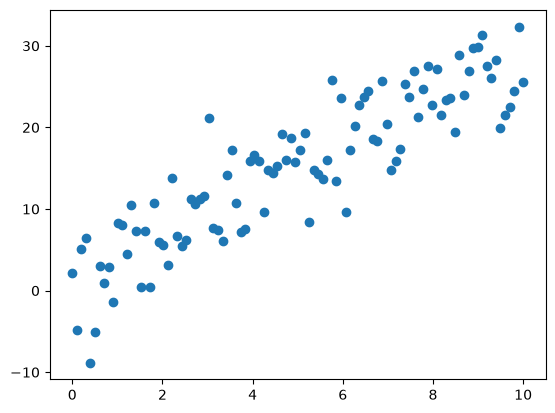

In [13]:
plt.plot(df_ruido["x"],df_ruido["y"], "o")
plt.show()

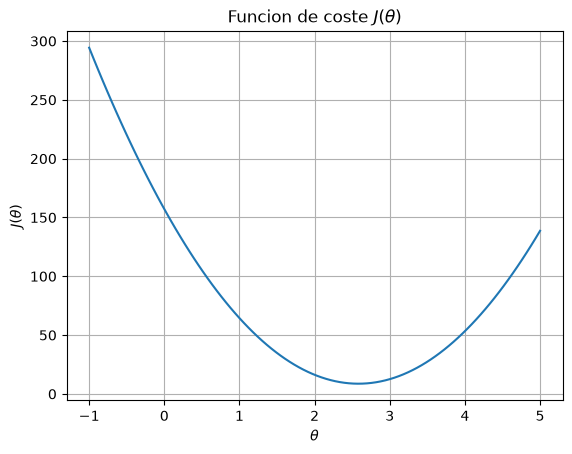

In [14]:
j = np.zeros(len(theta))

for i in range(len(theta)):
  j[i] = func_coste(df_ruido["x"],df_ruido["y"],theta[i],theta[i])

plt.plot(theta,j)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$J(\theta)$")
plt.title(r"Funcion de coste $J(\theta)$")
plt.grid()
plt.show()

In [15]:
X1, Y1 = np.meshgrid(theta, theta)

Z1 = np.zeros((len(theta),len(theta)))

for i in range(len(theta)):
  for j in range(len(theta)):
    Z1[i,j] = func_coste(df_ruido["x"],df_ruido["y"],theta[i], theta[j])

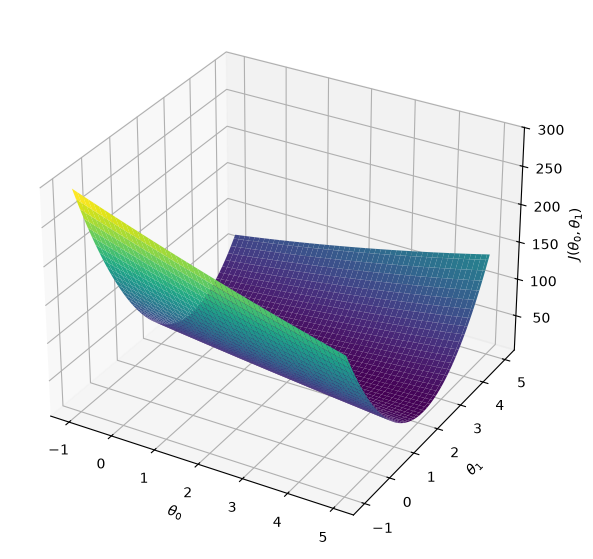

In [16]:
fig = plt.figure(figsize=(10,7))
ax = plt.axes( projection='3d')

ax.plot_surface(X1, Y1, Z1, cmap='viridis')
ax.set_xlabel(r"$\theta_0$")
ax.set_ylabel(r"$\theta_1$")
ax.set_zlabel(r"$J(\theta_0, \theta_1)$")
plt.show()

In [17]:
Z1_min = np.min(Z1)
x1_m, y1_m = np.unravel_index(np.argmin(Z1), Z1.shape)

X1_min = X1[x1_m, y1_m]
Y1_min = Y1[x1_m, y1_m]

print(f"Minimo global de datos con ruido: J({X1_min}, {Y1_min}) = {Z1_min}")

Minimo global de datos con ruido: J(1.4242424242424243, 2.757575757575758) = 8.490148046312099


# 7. Analice el efecto de introducir un valor atípico en el conjunto de datos. Discuta cómo cambia la solución y qué limitaciones presenta la función de coste cuadrática.

In [18]:
datos = df_ruido.copy()
datos["y_sin_ruido"] = df["y"]

residuos = datos['y'] - datos['y_sin_ruido']
std_residuos = residuos.std()

index = np.random.choice(datos.index, size = 1, replace=False) #datos atipicos

atipic = []
for i in index:
    n = rd.randint(0, 1)
    if n == 0:
        atipic.append(datos.loc[i, 'y'] + 6*std_residuos)
    else:   
        atipic.append(datos.loc[i, 'y'] - 6*std_residuos)

datos.loc[index, 'y'] = atipic

# minimos de la funcion de coste con datos atipicos

X2, Y2 = np.meshgrid(theta, theta)

Z2 = np.zeros((len(theta),len(theta)))

for i in range(len(theta)):
  for j in range(len(theta)):
    Z2[i,j] = func_coste(datos["x"],datos["y"],theta[i], theta[j])

Z2_min = np.min(Z2)
x2_m, y2_m = np.unravel_index(np.argmin(Z2), Z2.shape)

X2_min = X1[x2_m, y2_m]
Y2_min = Y1[x2_m, y2_m]

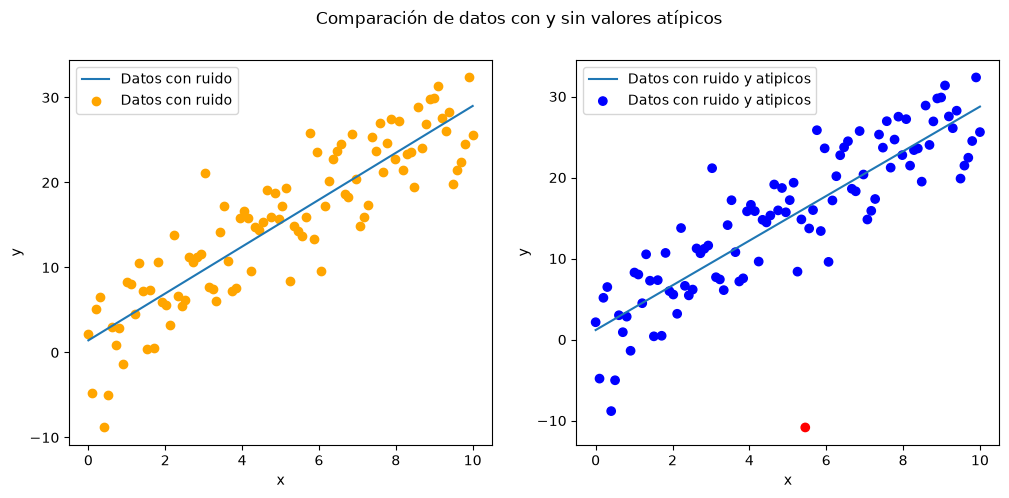

In [19]:
# Datos con ruido y sin ruido
y_pred = X1_min + Y1_min * df_ruido["x"]
y1_pred = X2_min + Y2_min * datos["x"]

colores = ['red' if datos.loc[i, 'y'] in atipic else 'blue' for i in range(len(datos))]

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,5))

ax1.plot(df_ruido["x"],y_pred, label="Datos con ruido")
ax1.scatter(df_ruido["x"],df_ruido["y"], label="Datos con ruido", color="orange")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.legend()

ax2.plot(datos["x"],y1_pred, label="Datos con ruido y atipicos")
ax2.scatter(datos["x"],datos["y"], label="Datos con ruido y atipicos", color=colores)
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.legend()

plt.suptitle("Comparación de datos con y sin valores atípicos")
plt.show()

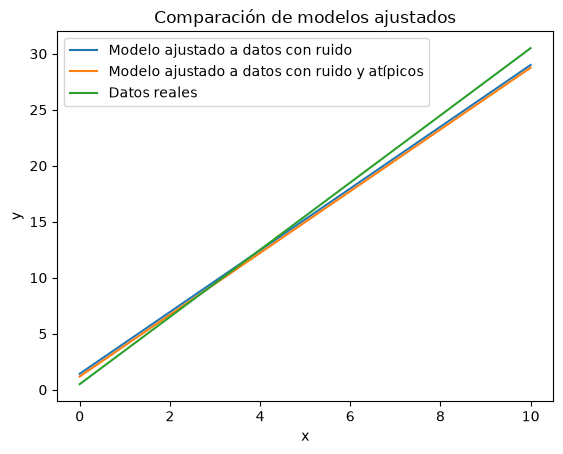

In [20]:
plt.plot(df_ruido["x"],y_pred, label="Modelo ajustado a datos con ruido")
plt.plot(datos["x"],y1_pred, label="Modelo ajustado a datos con ruido y atípicos")
plt.plot(df["x"],df["y"], label="Datos reales")

plt.title("Comparación de modelos ajustados")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# 8. Compare el ajuste obtenido con un modelo lineal sobre un conjunto de datos no lineales. Discuta si minimizar la función de coste garantiza que el modelo sea adecuado.

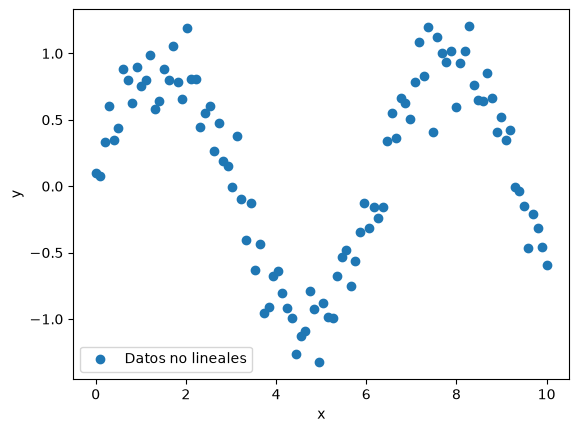

In [21]:
df_no_lineal = pd.DataFrame({
    "x": np.linspace(0, 10, 100),
    "y": np.sin(np.linspace(0, 10, 100))})

np.random.seed(42)  # Para mantener los mismos resultados aleatorios
ruido_sin = np.random.normal(0, 0.2, size=len(df_no_lineal["x"]))

df_no_lineal["y_ruido"] = df_no_lineal["y"] + ruido_sin



plt.scatter(df_no_lineal["x"], df_no_lineal["y_ruido"], label="Datos no lineales")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

Text(0.5, 0, '$J(\\theta_0, \\theta_1)$')

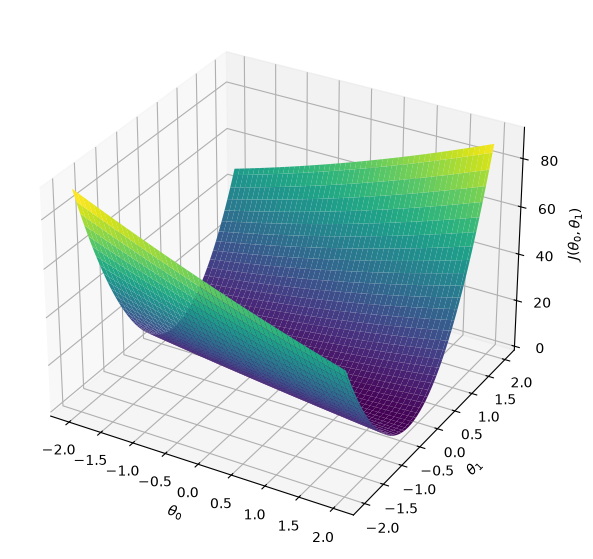

In [22]:
new_theta = np.linspace(-2, 2, 100)
j_no_lineal = np.zeros(len(new_theta))


X3, Y3 = np.meshgrid(new_theta, new_theta)

Z3 = np.zeros((len(new_theta),len(new_theta)))

for i in range(len(new_theta)):
    for j in range(len(new_theta)):
        Z3[i, j] = func_coste(df_no_lineal["x"], df_no_lineal["y_ruido"], new_theta[i], new_theta[j])

fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection='3d')
ax.plot_surface(X3, Y3, Z3, cmap='viridis')
ax.set_xlabel(r"$\theta_0$")
ax.set_ylabel(r"$\theta_1$")
ax.set_zlabel(r"$J(\theta_0, \theta_1)$")


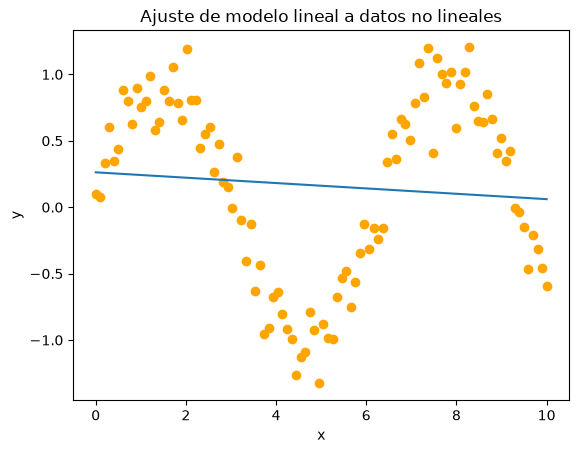

In [23]:
#minimo global de la funcion de coste con datos no lineales
minimo = np.min(Z3)

x3_m, y3_m = np.unravel_index(np.argmin(Z3), Z3.shape)

X3_min = X3[x3_m, y3_m]
Y3_min = Y3[x3_m, y3_m]

ajuste = X3_min + Y3_min * df_no_lineal["x"]

plt.plot(df_no_lineal["x"], ajuste, label="Datos no lineales")
plt.scatter(df_no_lineal["x"], df_no_lineal["y_ruido"], label="Datos no lineales", color="orange")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Ajuste de modelo lineal a datos no lineales")
plt.show()

No, minimizar la funcion de coste, no es suficiente para obtener un ajuste adecuado de los datos. para mejorar el ajuste habria que hallar valores de $\theta$ con un grado mas alto.

# 9. Obtenga la expresión teórica de la función de coste en el caso con un parámetro y con dos parámetros, e interprete el significado de sus mínimos.

Se define la funcion de coste como:

$$J(\theta_0,\theta_1,\dotsc,\theta_n) = \frac{1}{2m} \sum^m_{i=1} (\theta^Tx^{(i)}-y^{(y)})^2$$

un parametro $\theta_1$, suponiendo $\theta_0 = 0$

$$J(\theta_1) = \frac{1}{2m}\sum^m_{i=1}(\theta_1x_i-y_i)^2 \\ = \frac{1}{2m}\sum^m_{i=1}(\theta^2_1x^2_i - 2\theta_1x_iy_i + y_i) \\ = \frac{\theta^2_1}{2m}\sum^m_{i=1}x^2_i - \frac{\theta_1}{m}\sum^m_{i=1}x_iy_i + \frac{1}{2m}\sum^m_{i=1}y^2_i  $$

Definiendo los componentes de la expresion como

$$a = \sum^m_{i=i} = \frac{x_i^2}{2m} \\ b = \sum^m_{i=1} \frac{x_iy_i}{m} \\ c = \sum^m_{i = 1} \frac{y_i^2}{2m}$$

Entonces la expresion queda como

$$ J(\theta_1) = a\theta_1^2 - b\theta_1 + c$$

Que es la ecuacion de una parabola.

Minimos:

se obtienen de la siguiente forma

$$\frac{dJ(\theta_1)}{d\theta_1} = 2a\theta_1 - b = 0 \\ \theta_1 = \frac{b}{2a} = \frac{\sum x_iy_i}{\sum x_i}$$

Dos parametros $\theta_1$ y $\theta_0$

$$J(\theta_0,\theta_1) = \frac{1}{2m}\sum^m_{i = 1}(\theta_0 + theta_1x_i - y_i)^2 \\ \frac{1}{2m}\sum^m_{i=1}(\theta_0^2 + 2\theta_0(\theta_1x_i-y_i) + (\theta_1x_i - y_i)^2) \\ \frac{1}{2m}\sum^m_{i = 1}(\theta_0^2 + 2\theta_1\theta_0x_i - 2\theta_0y_i + \theta_1^2x_i^2 - 2\theta_1x_iy_i + y_i^2)$$

Minimos: 

$$\frac{\partial J}{\partial \theta_0} = \frac{1}{m}\sum^m_{i = 1}(\theta_0 + \theta_1x_i - y_i) = 0 \\ \frac{\partial J}{\partial \theta_1} = \frac{1}{m}\sum^m_{i = 1} (\theta_1x_i^2 + \theta_0 x_i - x_iy_i) = 0$$

# 10 . Construya un algoritmo en el que emplee el gradiente descendente para determinar el mínimo de una función. Determine dicho mínimo con un error $\epsilon$ de $10^{-4}$. Pruebe su algoritmo para $$f(x) = (x-4)^2$$ y al menos tres valores diferentes de $\alpha$.

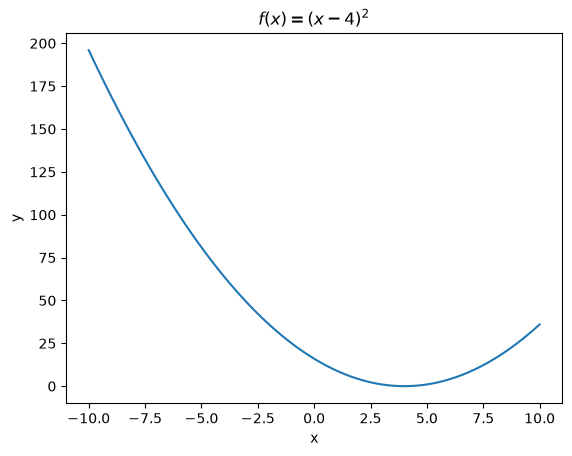

el minimo de la funcion es 3.9393939393939394 con valor f(x) = 0.0036730945821854847


In [24]:
#Gradiente descendente
import numpy as np

def grad_descent(f, w_init, epsilon, alpha, max_iter=10000):
    h = 1e-5
    w = w_init
    
    for _ in range(max_iter):
        grad = (f(w + h) - f(w - h)) / (2 * h)
        
        if abs(grad) < epsilon:
            break

        w = w - alpha * grad
        
    return w, f(w)

f = lambda x: (x-4)**2
x = np.linspace(-10,10,100)
y = list(f(x))
min_y = np.min(f(x))
min_x = x[y.index(min_y)]

#Funcion
plt.plot(x,f(x))
plt.title(r"$f(x) = (x-4)^2$")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

print(f"el minimo de la funcion es {min_x} con valor f(x) = {min_y}")


In [25]:
#prueba de la funcion

## alpha = 0.1
xalpha_1 , yalpha_1 = grad_descent(f,rd.choice(x),1e-14,0.5)
print(f"el minimo es: \n x = {xalpha_1} \n f(x) = {yalpha_1}")
print(r"\alpha = 0.5")

## alpha = 0.01
xalpha_2 , yalpha_2 = grad_descent(f,rd.choice(x),1e-14,0.1)
print(f"\n el minimo es: \n x = {xalpha_2} \n f(x) = {yalpha_2}")
print(r"\alpha = 0.1")

## alpha = 0.18
xalpha_3 , yalpha_3 = grad_descent(f,rd.choice(x),1e-14,0.8)
print(f"\n el minimo es: \n x = {xalpha_3} \n f(x) = {yalpha_3}")
print(r"\alpha = 0.8")

el minimo es: 
 x = 4.0 
 f(x) = 0.0
\alpha = 0.5

 el minimo es: 
 x = 3.999999999999995 
 f(x) = 2.3863042382935607e-29
\alpha = 0.1

 el minimo es: 
 x = 3.999999999999996 
 f(x) = 1.597443333072549e-29
\alpha = 0.8


# 11. Para responder este punto puede consultar la siguiente página y seguir el video de apoyo: Ejemplo guía: dotcsv. Encontrar el mínimo de la siguiente función a través del método del gradiente descendente: $$F(x,y) = sin(\frac{1}{2}x^2 - \frac{1}{4}y^2 + 3) cos(2x+1-e^y)$$ Para ello, realice una gráfica de la función en 3D y un mapa de contorno de la función.Determine el valor mínimo de la función con el método del gradiente descendente.

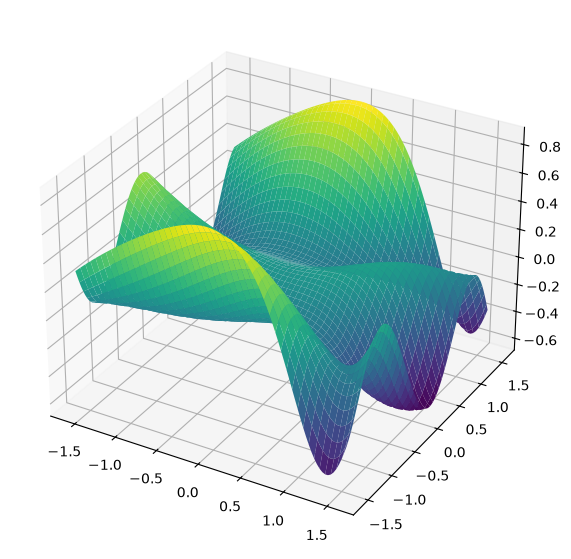

In [26]:
f_2d = lambda x,y : np.sin((1/2)*x**2 - (1/4)*y**2 +3)*np.cos(2*x + 1 - np.exp(y))
xi = np.linspace(-np.pi/2, np.pi/2,100)

X4, Y4 = np.meshgrid(xi,xi)

Yi = np.zeros((len(xi),len(xi)))

for i in range(len(xi)):
    for j in range(len(xi)):
        Yi[i,j] = f_2d(xi[i],xi[j])

fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection='3d')
ax.plot_surface(X4, Y4, Yi, cmap='viridis')
plt.show()

Convergió en la iteración 1409
Mínimo en (x, y): (2.201787, 1.687060)
Valor mínimo de la función F(x, y): -1.000000


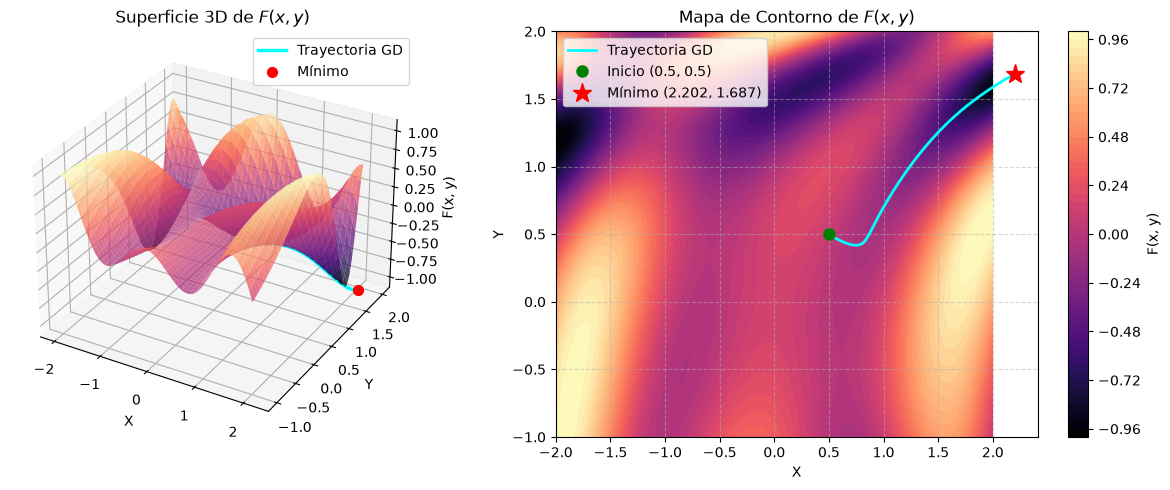

In [27]:
# 2. Gradiente numérico por diferencias finitas centrales
def gradient(x, y, h=1e-5):
    df_dx = (f_2d(x + h, y) - f_2d(x - h, y)) / (2 * h)
    df_dy = (f_2d(x, y + h) - f_2d(x, y - h)) / (2 * h)
    return np.array([df_dx, df_dy])

# 3. Algoritmo de Descenso de Gradiente
def gradient_descent(x_init, y_init, lr=0.01, tol=1e-14, max_iter=200000):
    point = np.array([x_init, y_init], dtype=np.float64)
    history = [point.copy()]
    
    for i in range(max_iter):
        grad = gradient(point[0], point[1])
        grad_norm = np.linalg.norm(grad)
        
        # Criterio de parada
        if grad_norm < tol:
            print(f"Convergió en la iteración {i}")
            break
            
        point -= lr * grad
        history.append(point.copy())
        
    return point, f_2d(point[0], point[1]), np.array(history)

x_start, y_start = 0.5, 0.5
min_point, min_val, path = gradient_descent(x_start, y_start, lr=0.01, tol=1e-14)

print(f"Mínimo en (x, y): ({min_point[0]:.6f}, {min_point[1]:.6f})")
print(f"Valor mínimo de la función F(x, y): {min_val:.6f}")


x_vals = np.linspace(-2, 2, 300)
y_vals = np.linspace(-1, 2, 300)
X, Y = np.meshgrid(x_vals, y_vals)
Z = f_2d(X, Y)

fig = plt.figure(figsize=(13, 5))


ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='magma', alpha=0.75, edgecolor='none')
z_path = [f_2d(p[0], p[1]) for p in path]
ax1.plot(path[:, 0], path[:, 1], z_path, color='cyan', linewidth=2.5, label='Trayectoria GD')
ax1.scatter([min_point[0]], [min_point[1]], [min_val], color='red', s=50, label='Mínimo')
ax1.set_title(r'Superficie 3D de $F(x, y)$')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('F(x, y)')
ax1.legend()

# Mapa de Contorno
ax2 = fig.add_subplot(1, 2, 2)
contour = ax2.contourf(X, Y, Z, levels=60, cmap='magma')
plt.colorbar(contour, ax=ax2, label='F(x, y)')
ax2.plot(path[:, 0], path[:, 1], color='cyan', linestyle='-', linewidth=2, label='Trayectoria GD')
ax2.plot(path[0, 0], path[0, 1], 'go', markersize=8, label=f'Inicio ({x_start}, {y_start})')
ax2.plot(min_point[0], min_point[1], 'r*', markersize=14, label=f'Mínimo ({min_point[0]:.3f}, {min_point[1]:.3f})')
ax2.set_title(r'Mapa de Contorno de $F(x, y)$')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

# 12. Empleando los siguientes datos: 
# X = np.linspace(0, 1, 100)
# y = 0.2 + 0.2*X + 0.02*np.random.random(100)
# y las herramientas desarrolladas en los apartados anteriores, construya un algorítmo que permita determinar una regresión lineal.

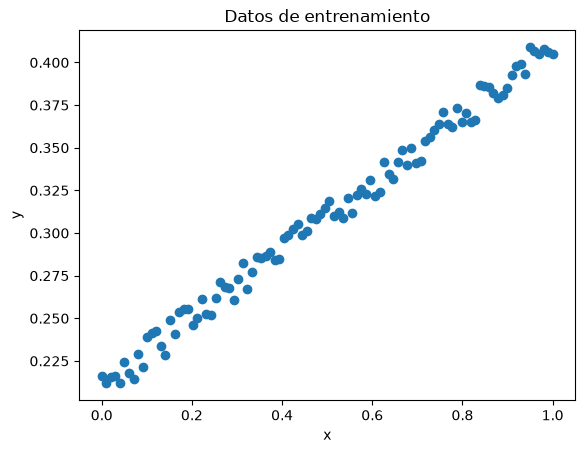

In [ ]:
x = np.linspace(0, 1, 100)
y = 0.2 + 0.2*x + 0.02*np.random.random(100)
plt.scatter(x,y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Datos de entrenamiento")
plt.show()

In [73]:
def reg_lineal(x,y,theta):
    #funcion de coste
    z = np.zeros((len(x), len(y)))
    for i in range(len(x)):
        for j in range(len(y)):
            z[i,j] = func_coste(x,y,theta[i],theta[j])
    
    #minimos
    min_x , min_y = np.unravel_index(np.argmin(z), z.shape)
    theta_0_min = theta[min_x]
    theta_1_min = theta[min_y]

    #predicciones
    y_pred = theta_0_min + theta_1_min * x

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(x, y, label="Datos de entrenamiento", color="blue")
    ax.plot(x, y_pred, label="Modelo ajustado", color="red")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Regresión Lineal")    
    ax.legend()

    return {"fig": fig, "theta_0_min": theta_0_min, "theta_1_min": theta_1_min}
    

Minimos de la funcion de coste: theta_0 = 0.21212121212121215, theta_1 = 0.21212121212121215


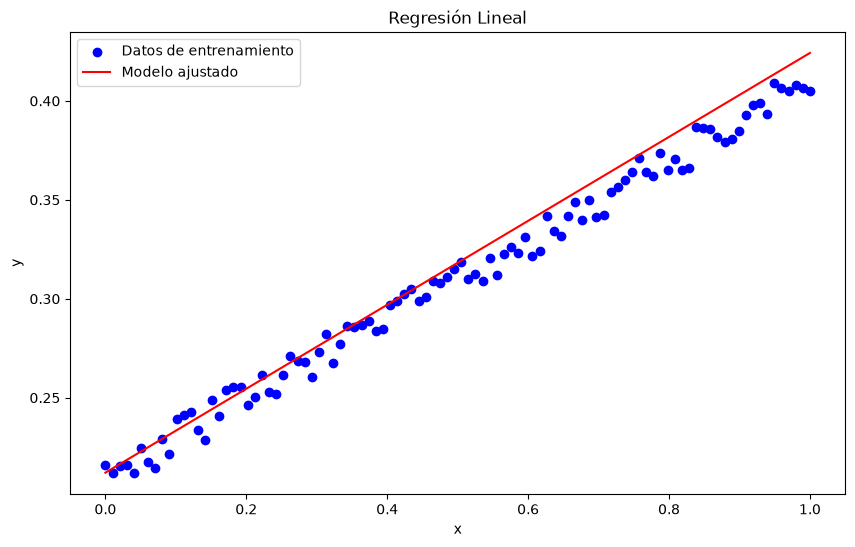

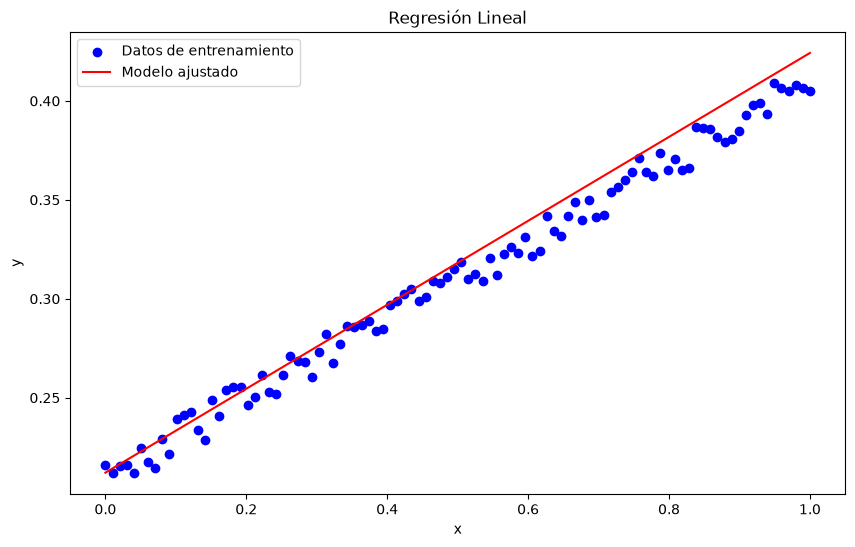

In [77]:
theta = np.linspace(-1, 5, 100)
resultado = reg_lineal(x,y,theta)
print(f"Minimos de la funcion de coste: theta_0 = {resultado['theta_0_min']}, theta_1 = {resultado['theta_1_min']}")
reg_lineal(x,y,theta)['fig']
plt.show()